In [ ]:
import dgl 
import os
import pickle
import networkx as nx
from scipy import sparse
import torch
import re 

data_name = 'eth'
graph_index = 1
graph_class = 3
# data_dir = "data/DBLP"   # or "data/DBLP/data/DBLP"
if data_name == 'sbm':
    data_dir = f"data/sbm_m{graph_class}/"
    dataset = []

    # for i in range(5):
    #     path = os.path.join(data_dir, f"graph_{i}_by_edges")
    #     with open(path, "rb") as f:
    #         g_dgl = pickle.load(f)
    #     nx_g = dgl.to_networkx(g_dgl).to_undirected()
    #     nx_g = nx.Graph(nx_g) 
    #     dataset.append(nx_g)
    # print(dataset)
    graph_number = 100
    for index in range(graph_number - 1):
        mat = sparse.load_npz(data_dir + f"G{graph_index}_graph_{index}_adj.npz")
        nx_g = nx.from_scipy_sparse_array(mat)
        nx_g = nx_g.to_undirected() 
        nx_g = nx.Graph(nx_g) 
        dataset.append(nx_g)
        
    node_counts = [g.number_of_nodes() for g in dataset]
    NVertices = min(node_counts)

    aligned_dataset = []

    for g in dataset:
        nodes_sorted = sorted(g.nodes())
        nodes_keep = nodes_sorted[:NVertices]
        g_sub = g.subgraph(nodes_keep).copy()
        # g_sub = nx.convert_node_labels_to_integers(g_sub)
        g_relabel = nx.convert_node_labels_to_integers(g_sub, ordering='sorted')
        aligned_dataset.append(g_relabel)

    dataset = aligned_dataset

elif data_name == 'eth':
    data_dir = "data/ETH_continual_graphs"
    dataset = []

    files = sorted(
        f for f in os.listdir(data_dir)
        if f.endswith("_continual_graph.pt")
    )
    all_labels = []
    for f in files:
        path = os.path.join(data_dir, f)

        data = torch.load(path)

        # ---- case 1: already networkx graph ----
        if isinstance(data, nx.Graph):
            nx_g = data

        # ---- case 2: PyG style ---
        elif hasattr(data, "edge_index"):
            edge_index = data.edge_index.cpu().numpy()
            nx_g = nx.Graph()
            edges = list(zip(edge_index[0], edge_index[1]))
            nx_g.add_edges_from(edges)

        # ---- case 3: DGL graph ----
        elif "graph" in data:
            import dgl
            nx_g = dgl.to_networkx(data["graph"]).to_undirected()

        # ---- case 4: adjacency matrix ----
        elif "adj" in data:
            nx_g = nx.from_numpy_array(data["adj"])

        else:
            raise ValueError("Unknown graph format in pt file")
        
        if hasattr(data, "y"):
            labels = data.y.cpu().numpy()
            all_labels.extend(labels)
        # ---- dictionary style ----
        elif isinstance(data, dict) and "node_label" in data:
            labels = data["node_label"]
            if torch.is_tensor(labels):
                labels = labels.cpu().numpy()
            all_labels.extend(labels)

        # ---- DGL style ----
        elif isinstance(data, dict) and "graph" in data:
            g = data["graph"]
            if "label" in g.ndata:
                labels = g.ndata["label"].cpu().numpy()
                all_labels.extend(labels)
        
        nx_g = nx.Graph(nx_g)
        dataset.append(nx_g)

    n_classes = len(set(all_labels))
    print("Total node classes:", n_classes)
    print("Classes:", sorted(set(all_labels)))
    node_counts = [g.number_of_nodes() for g in dataset]
    NVertices = min(node_counts)

    aligned_dataset = []

    for g in dataset:
        nodes_sorted = sorted(g.nodes())
        nodes_keep = nodes_sorted[:NVertices]
        g_sub = g.subgraph(nodes_keep).copy()
        # g_sub = nx.convert_node_labels_to_integers(g_sub)
        g_relabel = nx.convert_node_labels_to_integers(g_sub, ordering='sorted')
        aligned_dataset.append(g_relabel)

    dataset = aligned_dataset

elif data_name == 'ppi':
    data_dir = "data/ppi"
    dataset = []

    files = sorted(
        f for f in os.listdir(data_dir)
        if f.endswith("_continual_graph.pt")
    )
    all_labels = []
    for f in files:
        path = os.path.join(data_dir, f)

        data = torch.load(path)

        # ---- case 1: already networkx graph ----
        if isinstance(data, nx.Graph):
            nx_g = data

        # ---- case 2: PyG style ----
        elif hasattr(data, "edge_index"):
            edge_index = data.edge_index.cpu().numpy()
            nx_g = nx.Graph()
            edges = list(zip(edge_index[0], edge_index[1]))
            nx_g.add_edges_from(edges)

        # ---- case 3: DGL graph ----
        elif "graph" in data:
            import dgl
            nx_g = dgl.to_networkx(data["graph"]).to_undirected()

        # ---- case 4: adjacency matrix ----
        elif "adj" in data:
            nx_g = nx.from_numpy_array(data["adj"])

        else:
            raise ValueError("Unknown graph format in pt file")

        if hasattr(data, "y"):
            labels = data.y.cpu().numpy()
            all_labels.extend(labels)
        # ---- dictionary style ----
        elif isinstance(data, dict) and "node_label" in data:
            labels = data["node_label"]
            if torch.is_tensor(labels):
                labels = labels.cpu().numpy()
            all_labels.extend(labels)

        # ---- DGL style ----
        elif isinstance(data, dict) and "graph" in data:
            g = data["graph"]
            if "label" in g.ndata:
                labels = g.ndata["label"].cpu().numpy()
                all_labels.extend(labels)

        nx_g = nx.Graph(nx_g)
        dataset.append(nx_g)
    
    n_classes = len(set(all_labels))
    print("Total node classes:", n_classes)
    print("Classes:", sorted(set(all_labels)))
    node_counts = [g.number_of_nodes() for g in dataset]
    NVertices = min(node_counts)

    aligned_dataset = []

    for g in dataset:
        nodes_sorted = sorted(g.nodes())
        nodes_keep = nodes_sorted[:NVertices]
        g_sub = g.subgraph(nodes_keep).copy()
        # g_sub = nx.convert_node_labels_to_integers(g_sub)
        g_relabel = nx.convert_node_labels_to_integers(g_sub, ordering='sorted')
        aligned_dataset.append(g_relabel)

    dataset = aligned_dataset

elif data_name == 'DBLP_adj':
    data_dir = "data/DBLP_adj" 
    dataset = []

    files = sorted(
        [f for f in os.listdir(data_dir) if f.endswith("_adj.npz")],
        key=lambda x: int(re.search(r'graph_(\d+)_adj\.npz', x).group(1))
        if re.search(r'graph_(\d+)_adj\.npz', x) else x
    )

    print("Found files:", files)

    for f in files:
        path = os.path.join(data_dir, f)
        mat = sparse.load_npz(path)
        nx_g = nx.from_scipy_sparse_array(mat)
        nx_g = nx_g.to_undirected()
        nx_g = nx.Graph(nx_g)

        dataset.append(nx_g)

    print(f"Loaded {len(dataset)} graphs from adj.npz files")

    node_counts = [g.number_of_nodes() for g in dataset]
    print("Node counts:", node_counts)

    NVertices = 50
    print("Min number of nodes =", NVertices)

    aligned_dataset = []
    for g in dataset:
        degree_sorted_nodes = sorted(g.degree, key=lambda x: x[1], reverse=True)
        nodes_keep = [node for node, deg in degree_sorted_nodes[:NVertices]]
        g_sub = g.subgraph(nodes_keep).copy()
        g_relabel = nx.convert_node_labels_to_integers(g_sub, ordering='sorted')
        aligned_dataset.append(g_relabel)

    dataset = aligned_dataset

for i, g in enumerate(dataset):
    print(i, g.number_of_nodes(), g.number_of_edges())


Found files: ['graph_0_adj.npz', 'graph_1_adj.npz', 'graph_2_adj.npz', 'graph_3_adj.npz', 'graph_4_adj.npz', 'graph_5_adj.npz', 'graph_6_adj.npz', 'graph_7_adj.npz', 'graph_8_adj.npz', 'graph_9_adj.npz']
Loaded 10 graphs from adj.npz files
Node counts: [11348, 6024, 10118, 8278, 11580, 17059, 22436, 24687, 26611, 28094]
Min number of nodes = 50
0 50 73
1 50 44
2 50 73
3 50 69
4 50 65
5 50 23
6 50 16
7 50 3
8 50 0
9 50 0


In [ ]:
import os
import math
from tqdm import tqdm
import numpy as np
import pandas as pd
import networkx as nx
import ZIGZAG.zigzag.zigzagtools as zzt
from scipy.spatial.distance import squareform
import dionysus as d
import time
from scipy.stats import multivariate_normal
from ripser import Rips
from persim import PersistenceImager
import matplotlib.pyplot as plt


path = os.getcwd()

# NVertices = 307 # Number of vertices
scaleParameter = 1.0 # Scale Parameter (Maximum) # the maximal edge weight #
maxDimHoles = 2 # Maximum Dimension of Holes (It means.. 0 and 1)
sizeWindow = 3 # Number of Graphs

def edge_weight_function(G, alpha):
    deg = dict(G.degree())
    alpha = alpha

    scores = {(u, v): (deg[u] * deg[v]) ** alpha for u, v in G.edges()}
    mx = max(scores.values()) if scores else 1.0

    # 写入 edge weight
    for (u, v), s in scores.items():
        G[u][v]["weight"] = s / mx  # (0,1]

    return G


###
def zigzag_SBM_persistence_diagrams(dataset, NVertices, scaleParameter, maxDimHoles, sizeWindow, output_folder):
    # %% Generate Graph
    # GraphsNetX = []
    # window_PD = []
    assert sizeWindow <= len(dataset), "window size is exceed the dataset length, can not process!"
    start_index = sizeWindow - 1
    while start_index < len(dataset):
        GraphsNetX = []
        print(f"######## compute the window from {start_index - sizeWindow + 1} to {start_index} ########")
        for ii in range(start_index - sizeWindow + 1, start_index):
            # print(f"compute the window from {start_index - sizeWindow + 1} to {start_index}")
            tmp_g = dataset[ii]
            target_g = nx.empty_graph(NVertices)
            for u, v, w in tmp_g.edges(data="weight"):
                target_g.add_edge(int(u), int(v), weight = w)

            GraphsNetX.append(target_g)

        # %% Building unions and computing distance matrices
        GUnions = []
        MDisGUnions = []
        for i in range(0, sizeWindow - 2):
            # --- To concatenate graphs
            unionAux = []
            MDisAux = np.zeros((2 * NVertices, 2 * NVertices))
            A = nx.adjacency_matrix(GraphsNetX[i]).todense()
            B = nx.adjacency_matrix(GraphsNetX[i + 1]).todense()
            # ----- Version Original (2)
            C = (A + B) / 2
            A[A == 0] = 1.1
            A[range(NVertices), range(NVertices)] = 0
            B[B == 0] = 1.1
            B[range(NVertices), range(NVertices)] = 0
            MDisAux[0:NVertices, 0:NVertices] = A
            C[C == 0] = 1.1
            C[range(NVertices), range(NVertices)] = 0
            MDisAux[NVertices:(2 * NVertices), NVertices:(2 * NVertices)] = B
            MDisAux[0:NVertices, NVertices:(2 * NVertices)] = C
            MDisAux[NVertices:(2 * NVertices), 0:NVertices] = C.transpose()
            # Distance in condensed form
            pDisAux = squareform(MDisAux)
            # --- To save unions and distances
            GUnions.append(unionAux)  # To save union
            MDisGUnions.append(pDisAux)  # To save distance matrix

        # %% To perform Ripser computations
        GVRips = []
        for jj in range(0, sizeWindow - 2):
            print(jj)
            ripsAux = d.fill_rips(MDisGUnions[jj], maxDimHoles, scaleParameter)
            GVRips.append(ripsAux)

        # %% Shifting filtrations...
        GVRips_shift = []
        GVRips_shift.append(GVRips[0])  # Shift 0... original rips01
        for kk in range(1, sizeWindow - 2):
            shiftAux = zzt.shift_filtration(GVRips[kk], NVertices * kk)
            GVRips_shift.append(shiftAux)
        print(f"shift array size is {len(GVRips_shift)}")


        completeGVRips = GVRips_shift[0]
        for uu in range(1, len(GVRips_shift)):
            completeGVRips = zzt.complex_union(completeGVRips, GVRips_shift[uu])
            
        # %% To Combine complexes
        # completeGVRips = zzt.complex_union(GVRips[0], GVRips_shift[1])
        # if sizeWindow >= 4:
        #     for uu in range(2, sizeWindow - 2):
        #         completeGVRips = zzt.complex_union(completeGVRips, GVRips_shift[uu])

        # %% To compute the time intervals of simplices
        time_intervals = zzt.build_zigzag_times(completeGVRips, NVertices, sizeWindow)

        # %% To compute Zigzag persistence
        G_zz, G_dgms, G_cells = d.zigzag_homology_persistence(completeGVRips, time_intervals)
        print("  --- End Zigzag")  # Beginning

        # %% To show persistence intervals
        window_PD = []

        # %% Personalized plot
        for vv, dgm in enumerate(G_dgms):
            if (vv < 2):
                matBarcode = np.zeros((len(dgm), 2))
                k = 0
                for p in dgm:
                    matBarcode[k, 0] = p.birth
                    matBarcode[k, 1] = p.death
                    k = k + 1
                matBarcode = matBarcode / 2  ## final PD!!! ##
                window_PD.append(matBarcode)  # return list form
        np.save(f"{output_folder}/{start_index - sizeWindow + 1}_{start_index}_pd.npy", np.array(window_PD, dtype=object))
        start_index = start_index + 1
    # %%
    return window_PD


######## compute the window from 0 to 4 ########
0
1
2
shift array size is 3
  --- End Zigzag
######## compute the window from 1 to 5 ########
0
1
2
shift array size is 3
  --- End Zigzag
######## compute the window from 2 to 6 ########
0
1
2
shift array size is 3
  --- End Zigzag
######## compute the window from 3 to 7 ########
0
1
2
shift array size is 3
  --- End Zigzag
######## compute the window from 4 to 8 ########
0
1
2
shift array size is 3
  --- End Zigzag
######## compute the window from 5 to 9 ########
0
1
2
shift array size is 3
  --- End Zigzag
########## [[0.00054771 0.00055932 0.00057109 ... 0.00136761 0.00139438 0.00142171]
 [0.00055159 0.00056335 0.00057527 ... 0.00138374 0.00141089 0.0014386 ]
 [0.00055535 0.00056726 0.00057933 ... 0.00139972 0.00142725 0.00145534]
 ...
 [0.0006017  0.00061836 0.00063538 ... 0.00185537 0.0018938  0.00193273]
 [0.00060026 0.00061696 0.00063402 ... 0.00185758 0.00189606 0.00193503]
 [0.00059873 0.00061547 0.00063258 ... 0.00185939 0.001

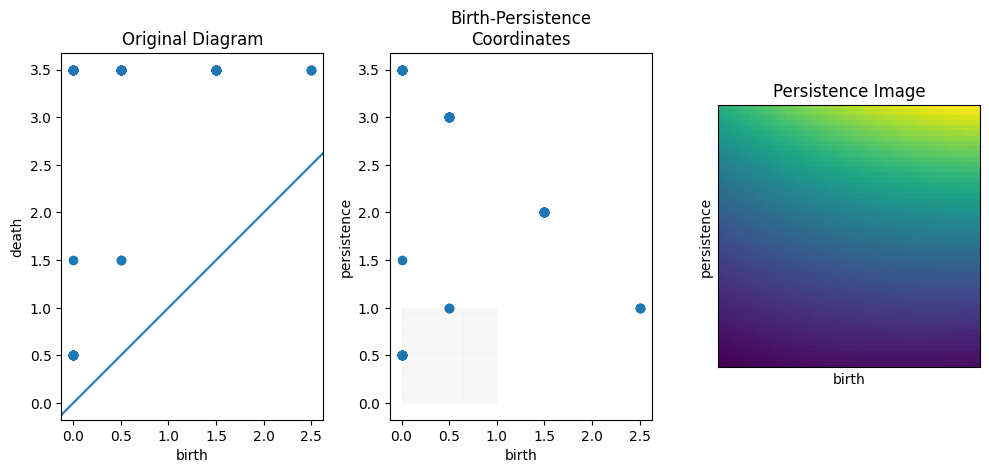

In [12]:
alpha = 0.5
edge_weight_dataset = []
for graph in dataset:
    edge_weight_dataset.append(edge_weight_function(graph, alpha))
output_folder = f"output/{data_name}_m{graph_class}/graph_{graph_index}/"
os.makedirs(output_folder, exist_ok=True)

# test = zigzag_SBM_persistence_diagrams(dataset = [edge_weight_function(g_0, alpha), edge_weight_function(g_1, alpha),
#                                                   edge_weight_function(g_2, alpha), edge_weight_function(g_3, alpha),
#                                                   edge_weight_function(g_4, alpha)], NVertices=300, scaleParameter=1.0, maxDimHoles=2, sizeWindow = 5)

test = zigzag_SBM_persistence_diagrams(dataset = edge_weight_dataset, NVertices=NVertices, scaleParameter=1.0, maxDimHoles=2, sizeWindow = sizeWindow, output_folder = output_folder)

# print(test)
pimgr = PersistenceImager(pixel_size=0.02)
pimgs = pimgr.transform(test, skew=True)
print(f"########## {pimgs[0]}")
# pimgs[0]

fig, axs = plt.subplots(1, 3, figsize=(10, 5))

axs[0].set_title("Original Diagram")
pimgr.plot_diagram(test[0], skew=False, ax=axs[0])

axs[1].set_title("Birth-Persistence\nCoordinates")
pimgr.plot_diagram(test[0], skew=True, ax=axs[1])

axs[2].set_title("Persistence Image")
pimgr.plot_image(pimgs[0], ax=axs[2])

plt.tight_layout()

In [13]:
import torch
import torch.nn.functional as F
import torch.nn as nn

# DNN 
class CNN(nn.Module):
    def __init__(self,input_channel, dim_out):
        super().__init__()

        self.features = nn.Sequential( 
            nn.Conv2d(input_channel, 16, 3, padding=1), 
            nn.ReLU(),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2),   # a → a/2

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
        )

        self.pool = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Linear(64, dim_out)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)


x = np.stack(pimgs, axis=0) 
x = torch.from_numpy(x).float()   # (2, H, W)
x = x.unsqueeze(0) # (1, 2, H, W)
print(f"before cnn x shape is {x.shape}")
output_dim = 64
cnn = CNN(input_channel=2, dim_out = output_dim)
x =  cnn(x)

print(f"after cnn x shape is {x.shape}")



before cnn x shape is torch.Size([1, 1, 50, 50])


RuntimeError: Given groups=1, weight of size [16, 2, 3, 3], expected input[1, 1, 50, 50] to have 2 channels, but got 1 channels instead

In [ ]:
class ExpandMLP(nn.Module):
    def __init__(self, d, n):
        super().__init__()
        self.n = n
        self.d = d
        
        self.mlp = nn.Sequential(
            nn.Linear(d, d),
            nn.ReLU(),
            nn.Linear(d, n * d)
        )

    def forward(self, x):
        # x: (B, d)
        x = self.mlp(x)               # (B, n*d)
        x = x.view(x.size(0), self.n, self.d)  # (B, n, d)
        return x

node_size = 4
mlp = ExpandMLP(d=output_dim, n = node_size)
x=mlp(x)
print(f"after mlp x shape is {x.shape}")